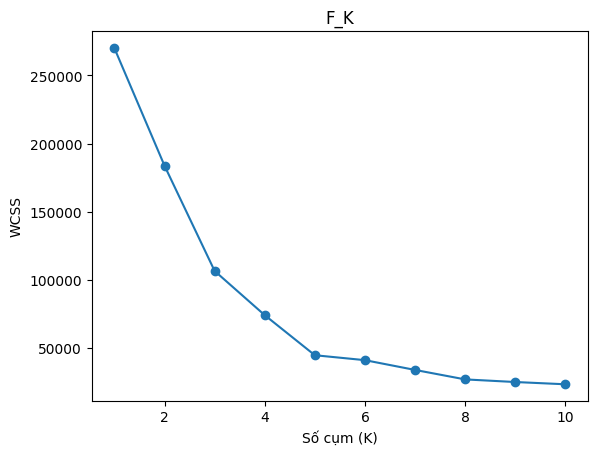

[[55.2962963  49.51851852]
 [86.53846154 82.12820513]
 [25.72727273 79.36363636]
 [88.2        17.11428571]
 [26.30434783 20.91304348]]


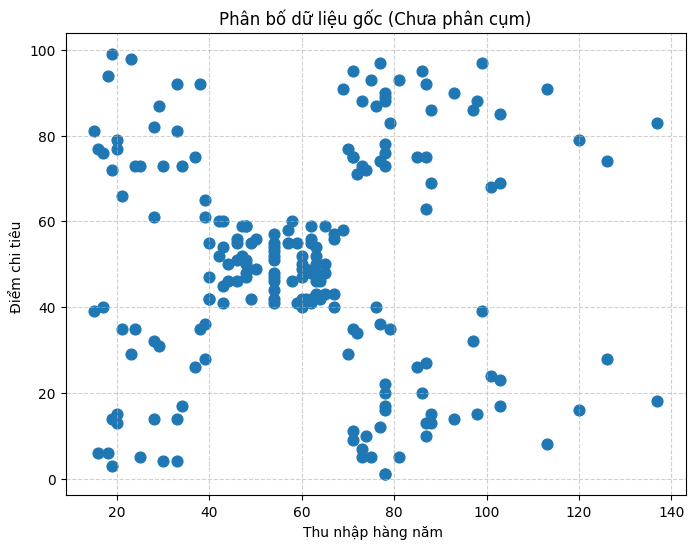

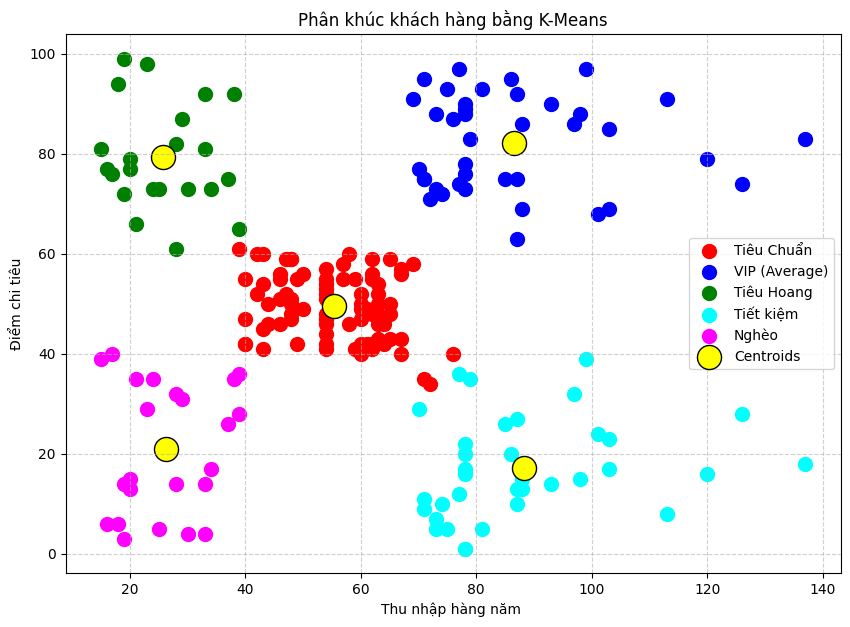

In [3]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import r2_score, mean_squared_error, accuracy_score  
from scipy.special import expit
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# 1. Giả sử ta có dữ liệu đơn giản như sau
data=pd.read_csv('D:\\Documents\\Mall_Customers.csv')
df =data
X = df.iloc[:, [3, 4]].values

# 2. Sử dụng Elbow Method để tìm K tối ưu
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

# Vẽ biểu đồ Elbow (điểm gãy của đường cong là K tốt nhất)
plt.plot(range(1, 11), wcss, marker='o')
plt.title('F_K')
plt.xlabel('Số cụm (K)')
plt.ylabel('WCSS')
plt.show()

# 3. Chạy K-Means với K=5 (con số phổ biến cho bài này)
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
y_kmeans = kmeans.fit_predict(X)
# In tọa độ tâm của 5 nhóm ra
print(kmeans.cluster_centers_)

# 4. Trực quan hóa kết quả
# 4. Trực quan hóa kết quả (Thêm Label cho X và Y)
plt.figure(figsize=(8,6))
plt.scatter(X[:, 0], X[:, 1], s=60)
plt.title("Phân bố dữ liệu gốc (Chưa phân cụm)")
plt.xlabel("Thu nhập hàng năm ")
plt.ylabel("Điểm chi tiêu ")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

plt.figure(figsize=(10, 7)) # Chỉnh kích thước cho dễ nhìn

# Vẽ từng cụm
plt.scatter(X[y_kmeans == 0, 0], X[y_kmeans == 0, 1], s=100, c='red', label='Tiêu Chuẩn')
plt.scatter(X[y_kmeans == 1, 0], X[y_kmeans == 1, 1], s=100, c='blue', label='VIP (Average)')
plt.scatter(X[y_kmeans == 2, 0], X[y_kmeans == 2, 1], s=100, c='green', label='Tiêu Hoang')
plt.scatter(X[y_kmeans == 3, 0], X[y_kmeans == 3, 1], s=100, c='cyan', label='Tiết kiệm ')
plt.scatter(X[y_kmeans == 4, 0], X[y_kmeans == 4, 1], s=100, c='magenta', label='Nghèo')

# Vẽ các điểm Centroids (Tâm cụm)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=300, c='yellow', label='Centroids', edgecolors='black')

# QUAN TRỌNG: Đặt tên cho các trục
plt.title('Phân khúc khách hàng bằng K-Means')
plt.xlabel('Thu nhập hàng năm ')
plt.ylabel('Điểm chi tiêu')
plt.legend() # Hiển thị bảng chú thích màu
plt.grid(True, linestyle='--', alpha=0.6) # Thêm lưới cho dễ soi tọa độ
plt.show()